## Cell 1 — Imports & setup

In [2]:
# Cell 1 — imports
import os
import pandas as pd
import numpy as np

from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8,5), "figure.dpi": 120})


## Cell 2 — Load cleaned ratings & movies

In [3]:
# Cell 2 — load data
ratings = pd.read_csv("data/processed/ratings_clean.csv")
movies = pd.read_csv("data/processed/movies_meta.csv")

ratings.head()


,userId,movieId,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


## STEP 1 — Load Data into Surprise

In [6]:
# Cell 3 — Surprise dataset
reader = Reader(rating_scale=(0.5, 5))

data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)

trainset = data.build_full_trainset()

print("Number of users:", trainset.n_users)
print("Number of items:", trainset.n_items)
print("Number of ratings:", trainset.n_ratings)


Number of users: 943
Number of items: 1682
Number of ratings: 100000


## STEP 2 — Train SVD Model

In [7]:
# Cell 4 — train SVD model
algo = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

algo.fit(trainset)

print("SVD model training completed.")


SVD model training completed.


## (Recommended) Evaluate model performance

In [8]:
# Cell 5 — train-test evaluation
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

algo_eval = SVD(random_state=42)
algo_eval.fit(train_data)

predictions = algo_eval.test(test_data)
rmse = accuracy.rmse(predictions)


RMSE: 0.9353


In [10]:
from surprise import accuracy

# Calculate MAE
mae = accuracy.mae(predictions)
print(f"MAE: {mae:.4f}")

# Calculate R²
def calculate_r_squared(predictions):
    y_true = [pred.r_ui for pred in predictions]
    y_pred = [pred.est for pred in predictions]
    y_mean = sum(y_true) / len(y_true)
    
    ss_total = sum((y - y_mean) ** 2 for y in y_true)
    ss_res = sum((y_true[i] - y_pred[i]) ** 2 for i in range(len(y_true)))
    
    r_squared = 1 - (ss_res / ss_total)
    return r_squared

r_squared = calculate_r_squared(predictions)
print(f"R²: {r_squared:.4f}")

MAE:  0.7377
MAE: 0.7377
R²: 0.3152


## STEP 3 — Rating Prediction Function

In [13]:
# Cell 6 — predict rating
def predict_rating(user_id, movie_id):
    """
    Predict rating a user would give to a movie
    """
    return algo.predict(user_id, movie_id).est

predict_rating(user_id=1, movie_id=50)


5

## STEP 4 — Top-N Recommendation Function (Collaborative Filtering)

In [15]:
# Cell 7 — Top-N CF recommender
def recommend_cf(user_id, n=10):
    """
    Recommend top-N movies to a user using collaborative filtering
    """
    # movies already rated by user
    rated_movie_ids = ratings[ratings['userId'] == user_id]['movieId'].unique()

    # unseen movies
    unseen_movies = movies[~movies['movieId'].isin(rated_movie_ids)].copy()

    # predict ratings for unseen movies
    unseen_movies['predicted_rating'] = unseen_movies['movieId'].apply(
        lambda movie_id: algo.predict(user_id, movie_id).est
    )

    # sort by predicted rating
    recommendations = unseen_movies.sort_values(
        by='predicted_rating',
        ascending=False
    ).head(n)

    return recommendations[['movieId', 'title', 'predicted_rating']]

recommend_cf(user_id=1, n=10)



,movieId,title,predicted_rating
512,513,"Third Man, The (1949)",4.890737
918,919,"City of Lost Children, The (1995)",4.890435
301,302,L.A. Confidential (1997),4.845106
275,276,Leaving Las Vegas (1995),4.841883
482,483,Casablanca (1942),4.822059
473,474,Dr. Strangelove or: How I Learned to Stop Worr...,4.802703
284,285,Secrets & Lies (1996),4.779155
507,508,"People vs. Larry Flynt, The (1996)",4.734003
317,318,Schindler's List (1993),4.733331
407,408,"Close Shave, A (1995)",4.712629


## Optional — Visualize recommendations

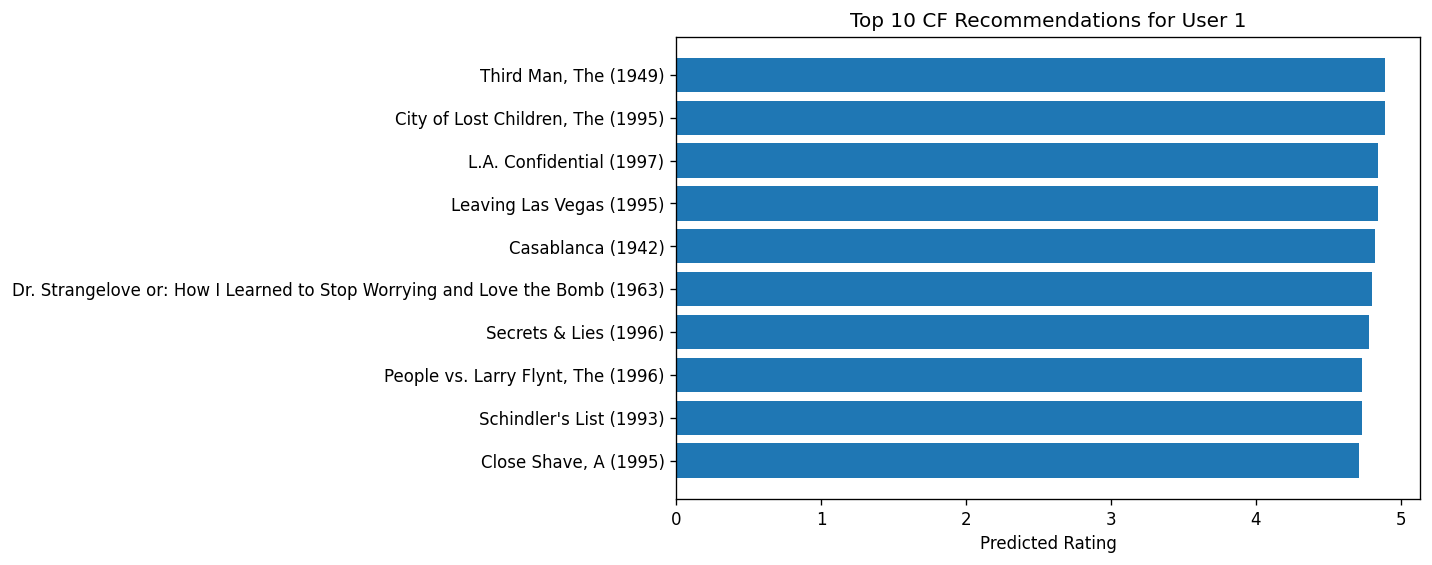

In [17]:
# Cell 9 — visualize recommendations
recs = recommend_cf(1, 10)

plt.barh(recs['title'][::-1], recs['predicted_rating'][::-1])
plt.xlabel("Predicted Rating")
plt.title("Top 10 CF Recommendations for User 1")
plt.show()


## Optional — Save trained model predictions (for hybrid phase)

In [18]:
# Cell 10 — save predictions (optional)
recs.to_csv("data/processed/sample_cf_recommendations.csv", index=False)
